In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
consumers = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
consumers.head()

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0


In [3]:
accounts = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt")
accounts.head()

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90


In [4]:
transactions = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt")
transactions.head()

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,3023,0,4,0.05,CREDIT,2021-04-16
1,3023,1,12,481.56,CREDIT,2021-04-30
2,3023,2,4,0.05,CREDIT,2021-05-16
3,3023,3,4,0.07,CREDIT,2021-06-16
4,3023,4,4,0.06,CREDIT,2021-07-16


In [5]:
category_mapping = pd.read_csv("/uss/hdsi-prismdata/q2-ucsd-cat-map.csv")
category_mapping

,category_id,category
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


In [6]:
# =======================
# Q2 Week 1/2 Homework Code
# =======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

# -----------------------
# 0) Make sure datetimes
# -----------------------
consumers = consumers.copy()
accounts = accounts.copy()
transactions = transactions.copy()
category_mapping = category_mapping.copy()

consumers["evaluation_date"] = pd.to_datetime(consumers["evaluation_date"], errors="coerce")
accounts["balance_date"] = pd.to_datetime(accounts["balance_date"], errors="coerce")
if "posted_date" in transactions.columns:
    transactions["posted_date"] = pd.to_datetime(transactions["posted_date"], errors="coerce")
elif "post_date" in transactions.columns:
    transactions["posted_date"] = pd.to_datetime(transactions["post_date"], errors="coerce")

# Keep only valid evaluation rows
consumers = consumers.dropna(subset=["prism_consumer_id", "evaluation_date", "DQ_TARGET"]).copy()
consumers["DQ_TARGET"] = consumers["DQ_TARGET"].astype(int)

print(consumers.shape, accounts.shape, transactions.shape)
consumers.head()


(12000, 4) (24466, 5) (6407321, 6)


,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0
1,1,2021-07-01,626.0,0
2,2,2021-05-01,680.0,0
3,3,2021-03-01,734.0,0
4,4,2021-10-01,676.0,0


Consumers in consDF: 12000
Consumers with accounts/balances: 13009
Consumers with transactions: 14492
Missing accounts: 1592 (13.27%)
Missing transactions: 399 (3.33%)


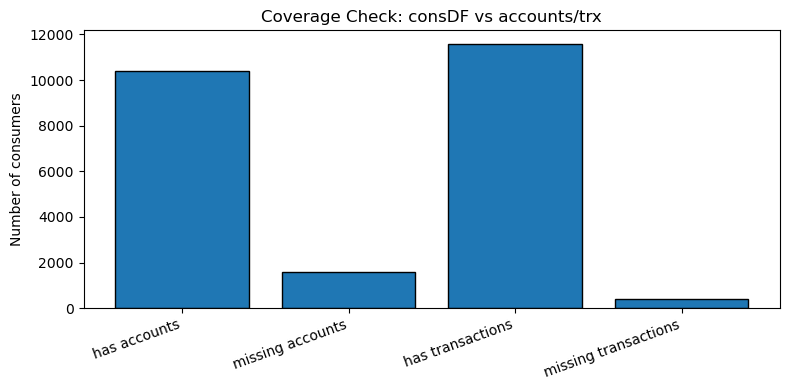

In [7]:
# -----------------------
# A1) Consumers missing accounts
# -----------------------
cons_ids = set(consumers["prism_consumer_id"].unique())
acct_ids = set(accounts["prism_consumer_id"].unique())
trx_ids  = set(transactions["prism_consumer_id"].unique())

missing_accounts = sorted(list(cons_ids - acct_ids))
missing_trx      = sorted(list(cons_ids - trx_ids))

print(f"Consumers in consDF: {len(cons_ids)}")
print(f"Consumers with accounts/balances: {len(acct_ids)}")
print(f"Consumers with transactions: {len(trx_ids)}")
print(f"Missing accounts: {len(missing_accounts)} ({len(missing_accounts)/len(cons_ids)*100:.2f}%)")
print(f"Missing transactions: {len(missing_trx)} ({len(missing_trx)/len(cons_ids)*100:.2f}%)")

# Quick graph
labels = ["has accounts", "missing accounts", "has transactions", "missing transactions"]
vals = [
    len(cons_ids) - len(missing_accounts),
    len(missing_accounts),
    len(cons_ids) - len(missing_trx),
    len(missing_trx)
]

plt.figure(figsize=(8,4))
plt.bar(labels, vals, edgecolor="black")
plt.title("Coverage Check: consDF vs accounts/trx")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of consumers")
plt.tight_layout()
plt.show()


In [8]:
# -----------------------
# B1) Map category_id -> category name
# -----------------------
cat_map = category_mapping.rename(columns={"category_id":"category"}).copy()
# cat_map now has columns: ["category", "category_name"]? depends on file
# From your screenshot: columns are category_id and category
# So fix for that:
cat_map = category_mapping.rename(columns={"category_id":"category_id", "category":"category_name"}).copy()

# If transactions column is named "category" and it's numeric IDs, rename to category_id
trx = transactions.copy()
if "category_id" not in trx.columns:
    trx = trx.rename(columns={"category":"category_id"})

trx = trx.merge(cat_map, on="category_id", how="left")
trx["category_name"] = trx["category_name"].fillna("UNKNOWN")

# -----------------------
# B2) Define income categories (ALL income)
# -----------------------
INCOME_CATS = {
    "PAYCHECK",
    "DEPOSIT",
    "OTHER_BENEFITS",
    "UNEMPLOYMENT_BENEFITS",
    "INVESTMENT_INCOME",
    "TAX",
    "REFUND"
}

# income = CREDIT side (money coming in)
trx["credit_or_debit"] = trx["credit_or_debit"].astype(str).str.upper()
trx["amount"] = pd.to_numeric(trx["amount"], errors="coerce")
trx = trx.dropna(subset=["prism_consumer_id", "posted_date", "amount", "credit_or_debit"])

# Keep only credit inflows AND income categories
income_trx = trx[
    (trx["credit_or_debit"] == "CREDIT") &
    (trx["category_name"].isin(INCOME_CATS)) &
    (trx["amount"] > 0)
].copy()

print("Income transactions:", income_trx.shape)
income_trx[["prism_consumer_id","posted_date","amount","category_name"]].head()


Income transactions: (400314, 7)


,prism_consumer_id,posted_date,amount,category_name
10,3023,2021-04-06,208.05,DEPOSIT
17,3023,2021-05-07,900.00,PAYCHECK
19,3023,2021-05-08,800.00,DEPOSIT
20,3023,2021-05-23,300.00,DEPOSIT
21,3023,2021-06-04,300.00,PAYCHECK


In [9]:
# -----------------------
# C1) Build "single best feature": pct_negative_balance_90d
# -----------------------
BAL_WINDOW_DAYS = 90

bal = accounts.copy()
bal["balance"] = pd.to_numeric(bal["balance"], errors="coerce")
bal = bal.dropna(subset=["prism_consumer_id","balance_date","balance"]).copy()

# Join balances onto consumers and filter to window before eval
bal_eval = bal.merge(
    consumers[["prism_consumer_id","evaluation_date","DQ_TARGET"]],
    on="prism_consumer_id",
    how="inner"
)

bal_eval["days_before_eval"] = (bal_eval["evaluation_date"] - bal_eval["balance_date"]).dt.days
bal_eval = bal_eval[(bal_eval["days_before_eval"] >= 0) & (bal_eval["days_before_eval"] <= BAL_WINDOW_DAYS)]

# Compute feature per consumer
single_feat = (
    bal_eval
    .groupby("prism_consumer_id")
    .agg(
        n_snapshots=("balance","size"),
        pct_negative_balance_90d=("balance", lambda s: (s < 0).mean()),
        min_balance_90d=("balance","min"),
        mean_balance_90d=("balance","mean"),
        std_balance_90d=("balance","std"),
        last_balance_90d=("balance", lambda s: s.iloc[-1])  # relies on current sort
    )
    .reset_index()
)

# Ensure last_balance_90d is truly last in time:
bal_eval_sorted = bal_eval.sort_values(["prism_consumer_id","balance_date"])
last_bal = bal_eval_sorted.groupby("prism_consumer_id")["balance"].last().rename("last_balance_90d").reset_index()
single_feat = single_feat.drop(columns=["last_balance_90d"]).merge(last_bal, on="prism_consumer_id", how="left")

df1 = consumers.merge(single_feat, on="prism_consumer_id", how="left")

print(df1[["pct_negative_balance_90d","min_balance_90d","mean_balance_90d","std_balance_90d","last_balance_90d"]].isna().mean())
df1.head()


pct_negative_balance_90d    0.196750
min_balance_90d             0.196750
mean_balance_90d            0.196750
std_balance_90d             0.520583
last_balance_90d            0.196750
dtype: float64


,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET,n_snapshots,pct_negative_balance_90d,min_balance_90d,mean_balance_90d,std_balance_90d,last_balance_90d
0,0,2021-09-01,726.0,0,2.0,0.0,25.70,160.185,190.190511,294.67
1,1,2021-07-01,626.0,0,2.0,0.0,91.24,1651.210,2206.130731,91.24
2,2,2021-05-01,680.0,0,2.0,0.0,243.93,1402.680,1638.719965,243.93
3,3,2021-03-01,734.0,0,2.0,0.0,976.82,3833.505,4039.962670,976.82
4,4,2021-10-01,676.0,0,1.0,0.0,391.62,391.620,NaN,391.62


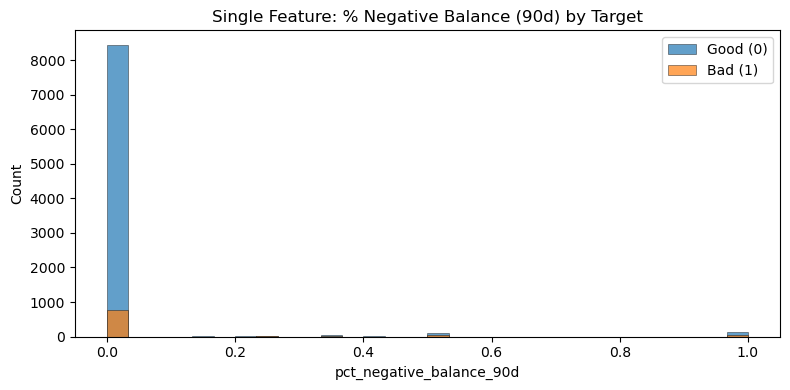

In [10]:
# -----------------------
# C2) Visualization: distribution by target
# -----------------------
plot_df = df1.dropna(subset=["pct_negative_balance_90d"]).copy()

good = plot_df[plot_df["DQ_TARGET"]==0]["pct_negative_balance_90d"]
bad  = plot_df[plot_df["DQ_TARGET"]==1]["pct_negative_balance_90d"]

plt.figure(figsize=(8,4))
plt.hist(good, bins=30, alpha=0.7, label="Good (0)", edgecolor="black", linewidth=0.4)
plt.hist(bad,  bins=30, alpha=0.7, label="Bad (1)",  edgecolor="black", linewidth=0.4)
plt.title("Single Feature: % Negative Balance (90d) by Target")
plt.xlabel("pct_negative_balance_90d")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


ROC-AUC: 0.5496
PR-AUC (Average Precision): 0.1200

Threshold = 0.2
Class 0 (Good):  precision=0.917 recall=0.965 f1=0.940 support=8751
Class 1 (Bad):   precision=0.283 recall=0.134 f1=0.182 support=888

Confusion Matrix [[TN FP],[FN TP]]:
 [[8449  302]
 [ 769  119]]


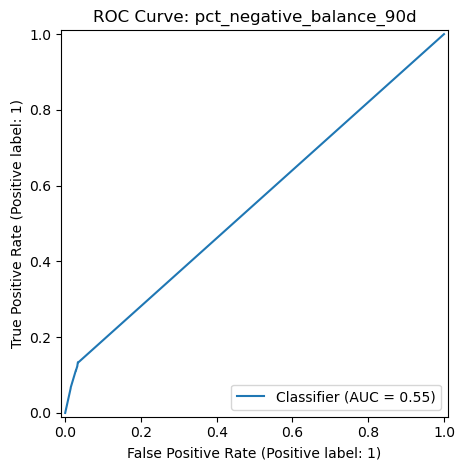

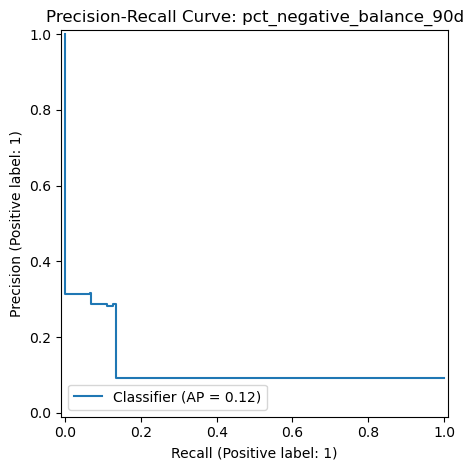

In [11]:
# -----------------------
# C3) Metrics
# -----------------------
eval_df = plot_df.copy()
y_true = eval_df["DQ_TARGET"].values
y_score = eval_df["pct_negative_balance_90d"].values  # higher => riskier

roc_auc = roc_auc_score(y_true, y_score)
pr_auc  = average_precision_score(y_true, y_score)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

# pick a simple threshold (you can tune later)
THRESH = 0.20
y_pred = (y_score >= THRESH).astype(int)

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0,1], zero_division=0
)

print("\nThreshold =", THRESH)
print("Class 0 (Good):  precision={:.3f} recall={:.3f} f1={:.3f} support={}".format(prec[0],rec[0],f1[0],support[0]))
print("Class 1 (Bad):   precision={:.3f} recall={:.3f} f1={:.3f} support={}".format(prec[1],rec[1],f1[1],support[1]))

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm)

# Curves (easy to show in meetings)
RocCurveDisplay.from_predictions(y_true, y_score)
plt.title("ROC Curve: pct_negative_balance_90d")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_true, y_score)
plt.title("Precision-Recall Curve: pct_negative_balance_90d")
plt.tight_layout()
plt.show()


Sample good IDs: ['11354' '6104' '8966' '1004' '6026']
Sample bad  IDs: ['13620' '5034' '7524' '8949' '8827']


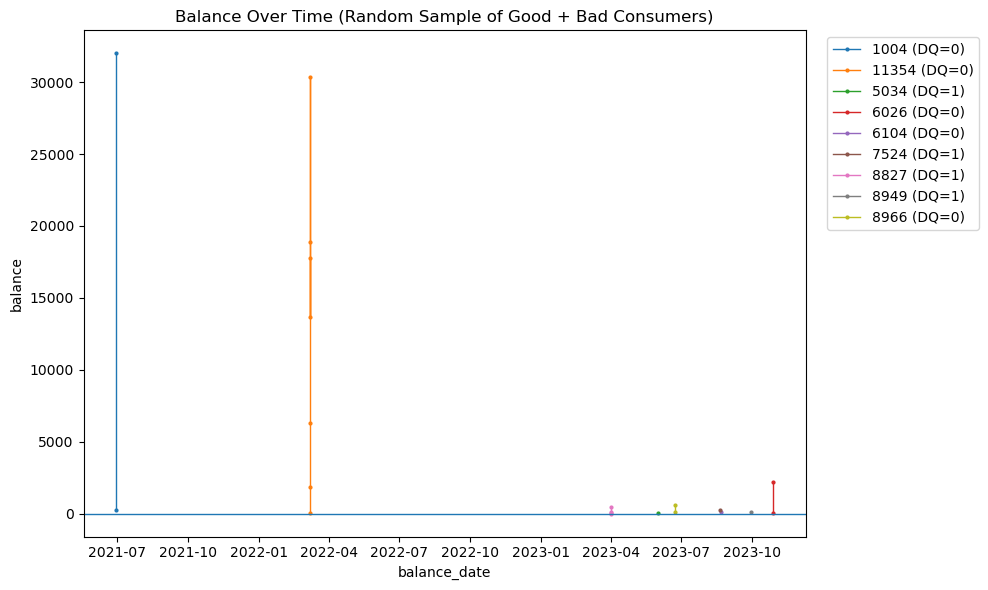

In [12]:
# -----------------------
# D1) Sample consumers
# -----------------------
N_SAMPLE = 5
rng = np.random.default_rng(42)

good_ids = consumers.loc[consumers["DQ_TARGET"]==0, "prism_consumer_id"].unique()
bad_ids  = consumers.loc[consumers["DQ_TARGET"]==1, "prism_consumer_id"].unique()

sample_good = rng.choice(good_ids, size=min(N_SAMPLE, len(good_ids)), replace=False)
sample_bad  = rng.choice(bad_ids,  size=min(N_SAMPLE, len(bad_ids)),  replace=False)

sample_ids = np.concatenate([sample_good, sample_bad])

print("Sample good IDs:", sample_good)
print("Sample bad  IDs:", sample_bad)

# -----------------------
# D2) Plot balance curves for each sampled consumer
# -----------------------
bal_sample = bal[bal["prism_consumer_id"].isin(sample_ids)].copy()
bal_sample = bal_sample.sort_values(["prism_consumer_id","balance_date"])

# Merge target for labeling
bal_sample = bal_sample.merge(consumers[["prism_consumer_id","DQ_TARGET"]], on="prism_consumer_id", how="left")

plt.figure(figsize=(10,6))
for cid, grp in bal_sample.groupby("prism_consumer_id"):
    label = f"{cid} (DQ={int(grp['DQ_TARGET'].iloc[0])})"
    plt.plot(grp["balance_date"], grp["balance"], marker="o", linewidth=1, markersize=2, label=label)

plt.axhline(0, linewidth=1)
plt.title("Balance Over Time (Random Sample of Good + Bad Consumers)")
plt.xlabel("balance_date")
plt.ylabel("balance")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [13]:
# -----------------------
# E1) Helper: slope of balance over time
# -----------------------
def slope_days(dates, values):
    # dates: datetime series, values: numeric series
    if len(values) < 2:
        return np.nan
    x = (dates - dates.min()).dt.days.astype(float).values
    y = values.astype(float).values
    if np.all(x == x[0]):
        return np.nan
    # simple least squares slope
    x_mean = x.mean()
    y_mean = y.mean()
    denom = ((x - x_mean)**2).sum()
    if denom == 0:
        return np.nan
    return ((x - x_mean)*(y - y_mean)).sum() / denom

# -----------------------
# E2) Balance features in a window before eval
# -----------------------
WINDOW_DAYS = 180

bal_eval2 = bal.merge(
    consumers[["prism_consumer_id","evaluation_date","DQ_TARGET"]],
    on="prism_consumer_id",
    how="inner"
).sort_values(["prism_consumer_id","balance_date"])

bal_eval2["days_before_eval"] = (bal_eval2["evaluation_date"] - bal_eval2["balance_date"]).dt.days
bal_eval2 = bal_eval2[(bal_eval2["days_before_eval"] >= 0) & (bal_eval2["days_before_eval"] <= WINDOW_DAYS)]

balance_feats = (
    bal_eval2
    .groupby("prism_consumer_id")
    .apply(lambda g: pd.Series({
        "bal_n": len(g),
        "bal_last": g["balance"].iloc[-1],
        "bal_mean": g["balance"].mean(),
        "bal_min": g["balance"].min(),
        "bal_max": g["balance"].max(),
        "bal_std": g["balance"].std(),
        "bal_pct_negative": (g["balance"] < 0).mean(),
        "bal_slope_per_day": slope_days(g["balance_date"], g["balance"]),
    }))
    .reset_index()
)

# -----------------------
# E2b) Additional Balance Curve Shape Features
# -----------------------

curve_180d = (
    bal_eval2
    .groupby(["prism_consumer_id", "balance_date"], as_index=False)["balance"]
    .sum()
    .sort_values(["prism_consumer_id", "balance_date"])
)

def _norm_slope_per_day(dates: pd.Series, values: pd.Series) -> float:
    """
    Normalized slope = (dollars/day) / (typical balance level).
    Why: raw slope isn't comparable across high/low balance consumers.
"""
    if len(values) < 2:
        return 0.0
    x = (dates - dates.min()).dt.days.astype(float).values
    y = values.astype(float).values
    if np.all(x == x[0]):
        return 0.0
    # slope from simple linear regression (polyfit degree 1)
    slope = np.polyfit(x, y, 1)[0]
    scale = np.mean(np.abs(y)) + 1.0
    return float(slope / scale)

def _recovery_ratio_after_min(dates: pd.Series, values: pd.Series) -> float:
    """
    Recovery ratio after minimum:
      (max after min - min) / (abs(min) + 1)
    Interpretation:
      - high => dipped but recovered strongly
      - low  => never recovered (stress)
    """
    if len(values) < 2:
        return 0.0
    g = pd.DataFrame({"d": dates.values, "v": values.values}).sort_values("d")
    min_pos = g["v"].idxmin()
    vmin = float(g.loc[min_pos, "v"])
    post = g.loc[g.index > min_pos, "v"]
    if len(post) == 0:
        return 0.0
    return float((post.max() - vmin) / (abs(vmin) + 1.0))

def _momentum_late_minus_early(dates: pd.Series, values: pd.Series) -> float:
    """
    Momentum = late-half mean - early-half mean.
    Captures recent deterioration or improvement without being too sensitive to outliers.
    """
    if len(values) < 2:
        return 0.0
    g = pd.DataFrame({"d": dates.values, "v": values.values}).sort_values("d")
    mid = g["d"].min() + (g["d"].max() - g["d"].min()) / 2
    early = g.loc[g["d"] <= mid, "v"]
    late  = g.loc[g["d"] >  mid, "v"]
    if len(early) == 0 or len(late) == 0:
        return 0.0
    return float(late.mean() - early.mean())

def _recent_drop_last_k(dates: pd.Series, values: pd.Series, k: int = 3) -> float:
    """
    Recent drop using last k snapshots: last - first (within the last k).
    Negative => balance fell recently (potential stress).
    """
    if len(values) < 2:
        return 0.0
    g = pd.DataFrame({"d": dates.values, "v": values.values}).sort_values("d")
    tail = g.tail(k)
    if len(tail) < 2:
        return 0.0
    return float(tail["v"].iloc[-1] - tail["v"].iloc[0])


extra_shape_feats = (
    curve_180d
    .groupby("prism_consumer_id")
    .apply(lambda g: pd.Series({
        # Volatility relative to level: instability signal
        "bal_cv_180d": float(g["balance"].std() / (g["balance"].mean() + 1.0)) if len(g) > 1 else 0.0,

        # Normalized trend (comparable across consumers)
        "bal_norm_slope_180d": _norm_slope_per_day(g["balance_date"], g["balance"]),

        # Downside exposure: deeper/more frequent negatives matter
        "bal_neg_depth_180d": float(g.loc[g["balance"] < 0, "balance"].sum()),  # more negative => worse
        "bal_pct_negative_180d": float((g["balance"] < 0).mean()),

        # Shape behavior: do they recover after hitting a low?
        "bal_recovery_ratio_180d": _recovery_ratio_after_min(g["balance_date"], g["balance"]),

        # Recent vs earlier behavior
        "bal_momentum_180d": _momentum_late_minus_early(g["balance_date"], g["balance"]),
        "bal_recent_drop_180d": _recent_drop_last_k(g["balance_date"], g["balance"], k=3),
    }))
    .reset_index()
)

balance_feats = balance_feats.merge(extra_shape_feats, on="prism_consumer_id", how="left")

# Fill missing values for consumers with no/sparse balance history in this window
new_cols = [
    "bal_cv_180d",
    "bal_norm_slope_180d",
    "bal_neg_depth_180d",
    "bal_pct_negative_180d",
    "bal_recovery_ratio_180d",
    "bal_momentum_180d",
    "bal_recent_drop_180d",
]
for c in new_cols:
    balance_feats[c] = balance_feats[c].fillna(0.0)


    
# -----------------------
# E3) Income features in a window before eval
# -----------------------
income_eval = income_trx.merge(
    consumers[["prism_consumer_id","evaluation_date","DQ_TARGET"]],
    on="prism_consumer_id",
    how="inner"
)

income_eval["days_before_eval"] = (income_eval["evaluation_date"] - income_eval["posted_date"]).dt.days
income_eval = income_eval[(income_eval["days_before_eval"] >= 0) & (income_eval["days_before_eval"] <= WINDOW_DAYS)]

# monthly income estimate: total / months active in window
income_eval["month"] = income_eval["posted_date"].dt.to_period("M")

income_feats = (
    income_eval
    .groupby("prism_consumer_id")
    .apply(lambda g: pd.Series({
        "inc_n": len(g),
        "inc_total_180d": g["amount"].sum(),
        "inc_mean": g["amount"].mean(),
        "inc_std": g["amount"].std(),
        "inc_n_months": g["month"].nunique(),
        "inc_monthly_est": g["amount"].sum() / max(g["month"].nunique(), 1),
        "paycheck_n": (g["category_name"]=="PAYCHECK").sum(),
        "paycheck_share": (g["category_name"]=="PAYCHECK").mean() if len(g)>0 else np.nan,
        # regularity proxy: std of gaps between paycheck dates (lower = more regular)
        "paycheck_gap_std": (
            g.loc[g["category_name"]=="PAYCHECK"]
             .sort_values("posted_date")["posted_date"]
             .diff().dt.days.std()
        )
    }))
    .reset_index()
)

# -----------------------
# E4) Combine into modeling table
# -----------------------
feature_table = (
    consumers[["prism_consumer_id","DQ_TARGET","evaluation_date"]]
    .merge(balance_feats, on="prism_consumer_id", how="left")
    .merge(income_feats,  on="prism_consumer_id", how="left")
)

print("Feature table shape:", feature_table.shape)
feature_table.head()

/tmp/ipykernel_1559/3968688143.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_1559/3968688143.py:127: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Feature table shape: (12000, 27)


/tmp/ipykernel_1559/3968688143.py:183: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,prism_consumer_id,DQ_TARGET,evaluation_date,bal_n,bal_last,bal_mean,bal_min,bal_max,bal_std,bal_pct_negative,...,bal_recent_drop_180d,inc_n,inc_total_180d,inc_mean,inc_std,inc_n_months,inc_monthly_est,paycheck_n,paycheck_share,paycheck_gap_std
0,0,0,2021-09-01,2.0,294.67,160.185,25.70,294.67,190.190511,0.0,...,0.0,12.0,10193.74,849.478333,452.986190,6.0,1698.956667,8.0,0.666667,10.279429
1,1,0,2021-07-01,2.0,91.24,1651.210,91.24,3211.18,2206.130731,0.0,...,0.0,18.0,14780.94,821.163333,326.466173,7.0,2111.562857,13.0,0.722222,2.855086
2,2,0,2021-05-01,2.0,243.93,1402.680,243.93,2561.43,1638.719965,0.0,...,0.0,6.0,7250.96,1208.493333,1802.679936,5.0,1450.192000,0.0,0.000000,NaN
3,3,0,2021-03-01,2.0,976.82,3833.505,976.82,6690.19,4039.962670,0.0,...,0.0,10.0,10066.06,1006.606000,1273.803031,5.0,2013.212000,2.0,0.200000,NaN
4,4,0,2021-10-01,1.0,391.62,391.620,391.62,391.62,NaN,0.0,...,0.0,15.0,7660.32,510.688000,364.987688,3.0,2553.440000,0.0,0.000000,NaN


In [14]:
# Balance Curve Shape Features

added_balance_features = [
    "bal_cv_180d",
    "bal_norm_slope_180d",
    "bal_pct_negative_180d",
    "bal_recovery_ratio_180d",
    "bal_momentum_180d",
    "bal_recent_drop_180d",
]

# Only show consumers with enough balance history
# (shape features need multiple points to be meaningful)

shape_ready = feature_table[feature_table["bal_n"] >= 4]

shape_ready[
    ["prism_consumer_id", "DQ_TARGET", "bal_n"] + added_balance_features
].head(12)

,prism_consumer_id,DQ_TARGET,bal_n,bal_cv_180d,bal_norm_slope_180d,bal_pct_negative_180d,bal_recovery_ratio_180d,bal_momentum_180d,bal_recent_drop_180d
186,186,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
318,318,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
335,335,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
566,566,0,4.0,0.168715,-0.238599,0.0,0.000000,-21.530,-21.53
645,645,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
786,786,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
927,927,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
963,963,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
1025,1025,0,6.0,0.000000,0.000000,0.0,0.000000,0.000,0.00
1092,1092,0,4.0,0.000000,0.000000,0.0,0.000000,0.000,0.00


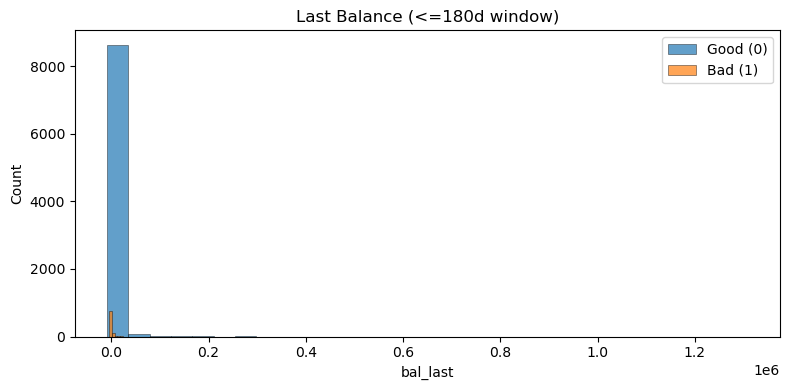

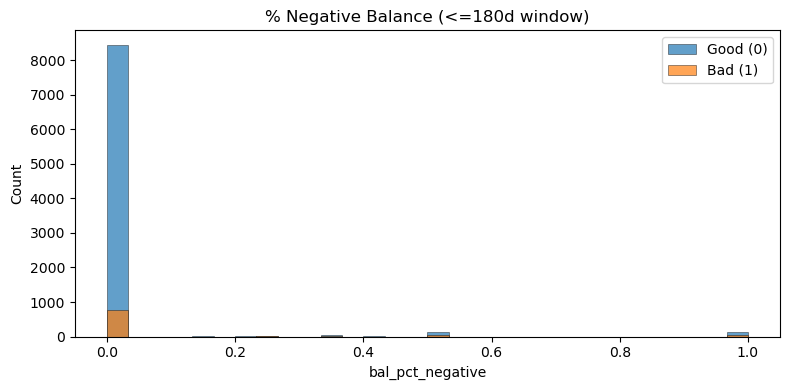

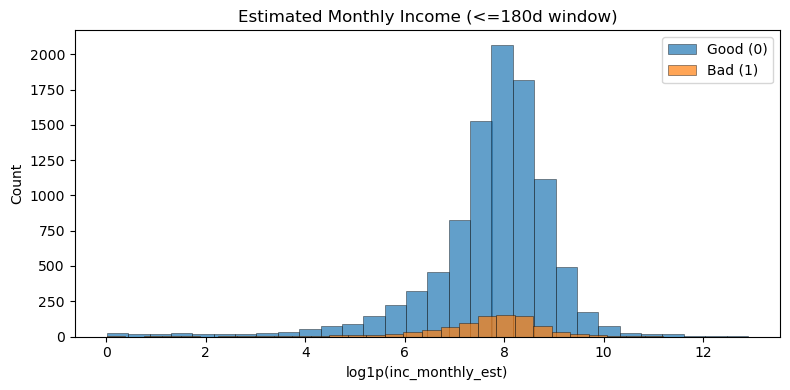

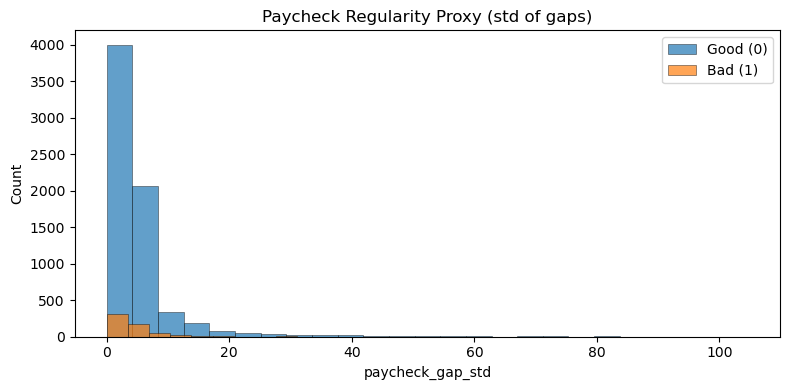

In [15]:
# -----------------------
# E5) Quick feature plots (good vs bad)
# -----------------------
def plot_feature_by_target(df, col, title=None, bins=30, logx=False):
    d = df.dropna(subset=[col]).copy()
    g0 = d[d["DQ_TARGET"]==0][col]
    g1 = d[d["DQ_TARGET"]==1][col]
    plt.figure(figsize=(8,4))
    if logx:
        g0 = np.log1p(g0)
        g1 = np.log1p(g1)
        plt.xlabel(f"log1p({col})")
    else:
        plt.xlabel(col)
    plt.hist(g0, bins=bins, alpha=0.7, label="Good (0)", edgecolor="black", linewidth=0.4)
    plt.hist(g1, bins=bins, alpha=0.7, label="Bad (1)",  edgecolor="black", linewidth=0.4)
    plt.title(title or f"{col} by Target")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_feature_by_target(feature_table, "bal_last", title="Last Balance (<=180d window)")
plot_feature_by_target(feature_table, "bal_pct_negative", title="% Negative Balance (<=180d window)")
plot_feature_by_target(feature_table, "inc_monthly_est", title="Estimated Monthly Income (<=180d window)", logx=True)
plot_feature_by_target(feature_table, "paycheck_gap_std", title="Paycheck Regularity Proxy (std of gaps)", bins=25)


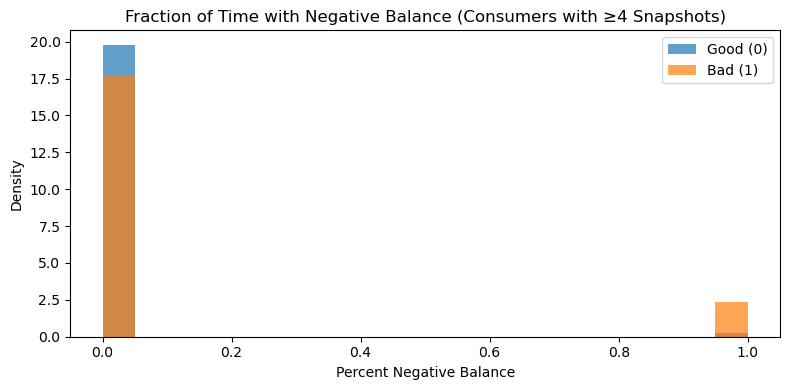

In [16]:
plot_df = feature_table[feature_table["bal_n"] >= 4]

good = plot_df[plot_df["DQ_TARGET"] == 0]["bal_pct_negative_180d"]
bad  = plot_df[plot_df["DQ_TARGET"] == 1]["bal_pct_negative_180d"]

plt.figure(figsize=(8,4))
plt.hist(good, bins=20, alpha=0.7, density=True, label="Good (0)")
plt.hist(bad,  bins=20, alpha=0.7, density=True, label="Bad (1)")

plt.title("Fraction of Time with Negative Balance (Consumers with ≥4 Snapshots)")
plt.xlabel("Percent Negative Balance")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()